<a href="https://colab.research.google.com/github/ishanwa/Forecasting_project/blob/main/CatBoost/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [2]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [4]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100


Processing: RevenueCenter_5


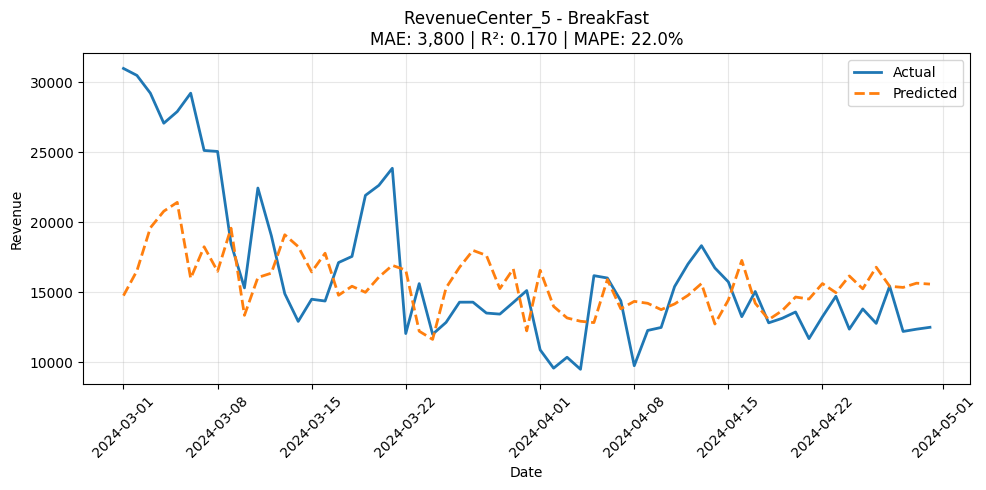

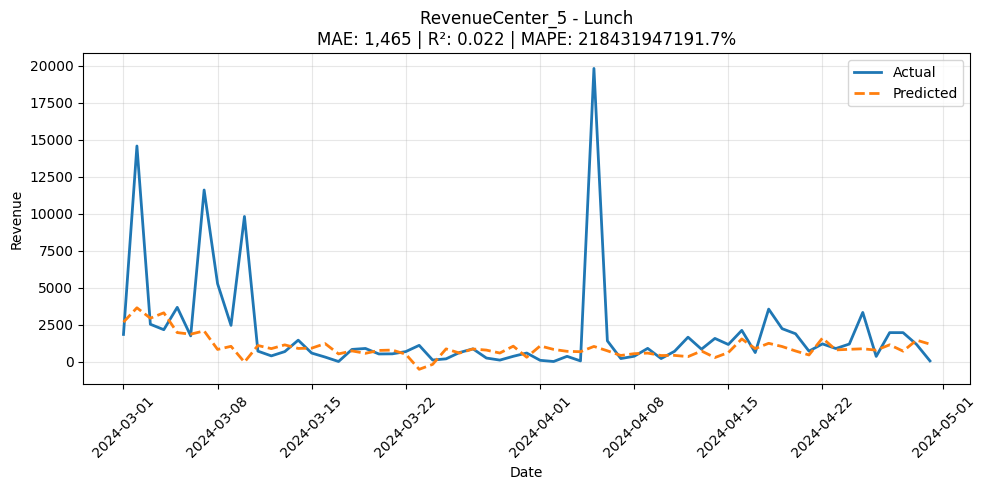

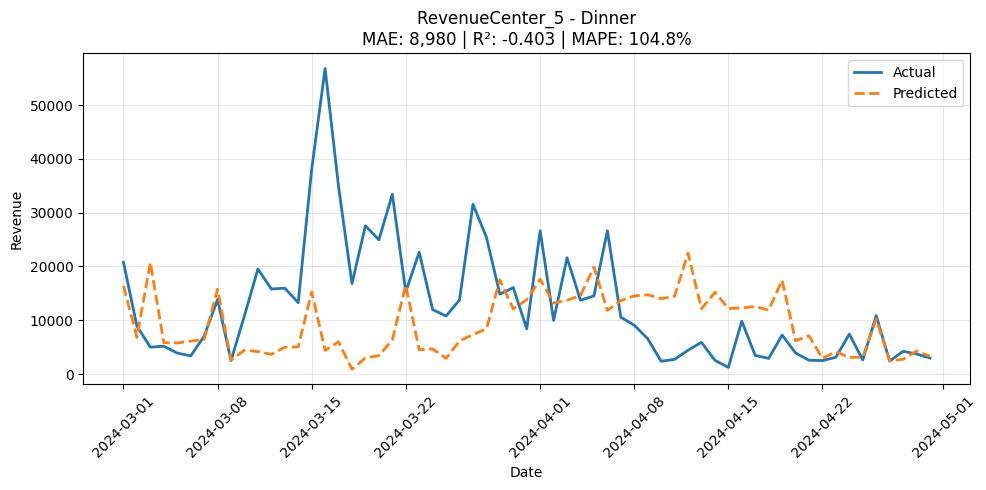

Saved plots & Excel → /content/RevenueCenter_5

Processing: RevenueCenter_7


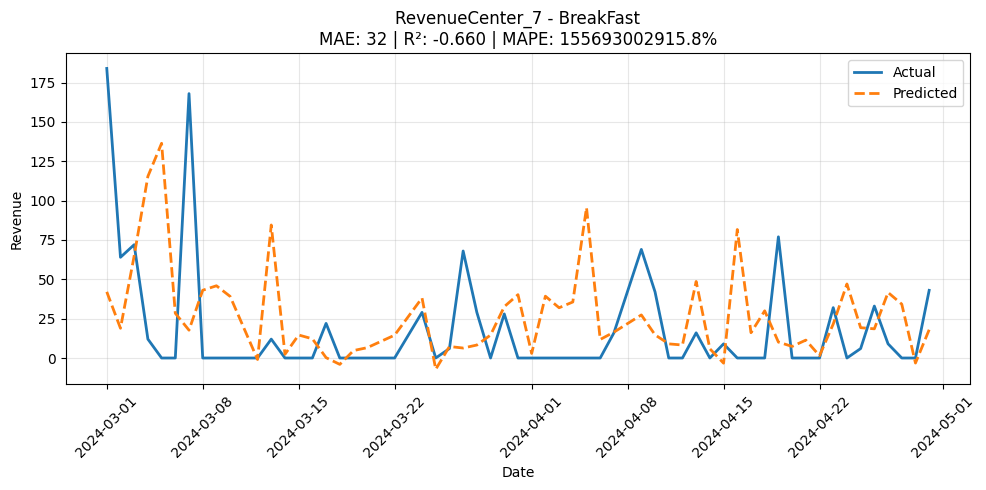

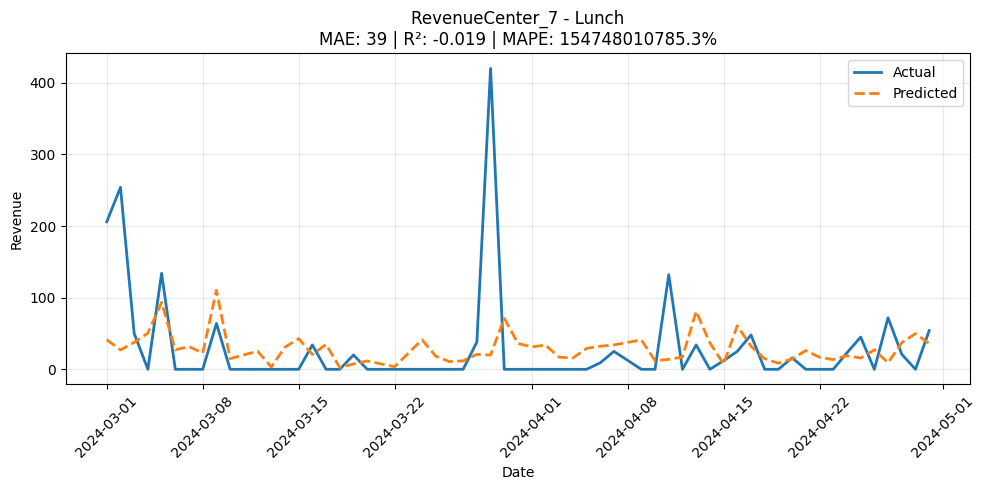

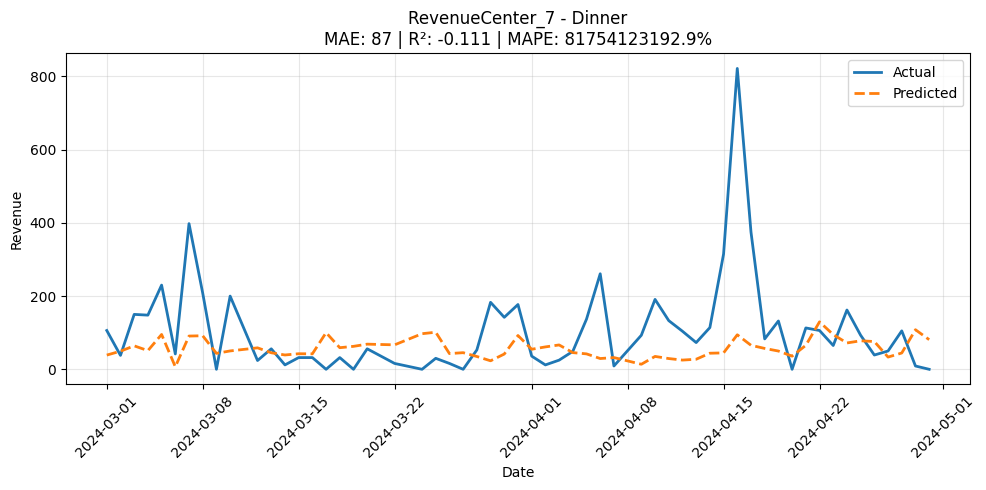

Saved plots & Excel → /content/RevenueCenter_7

Processing: RevenueCenter_8


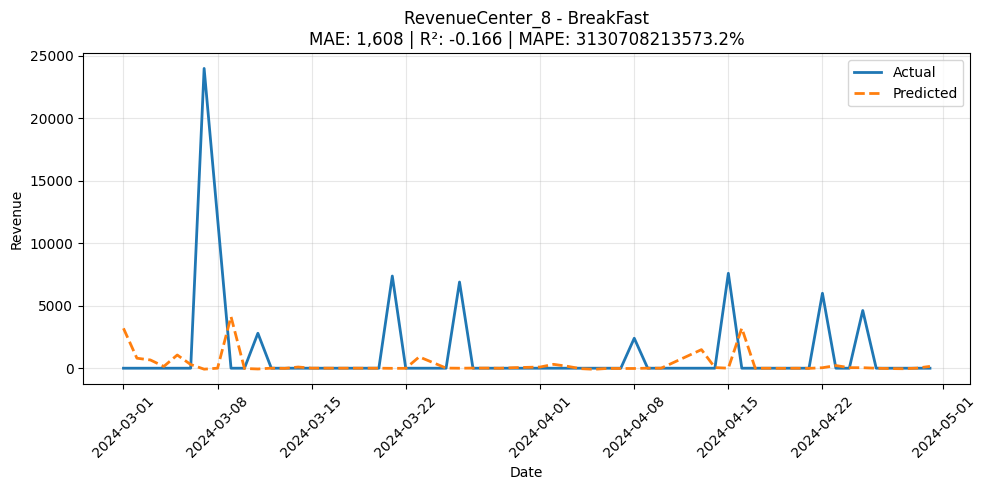

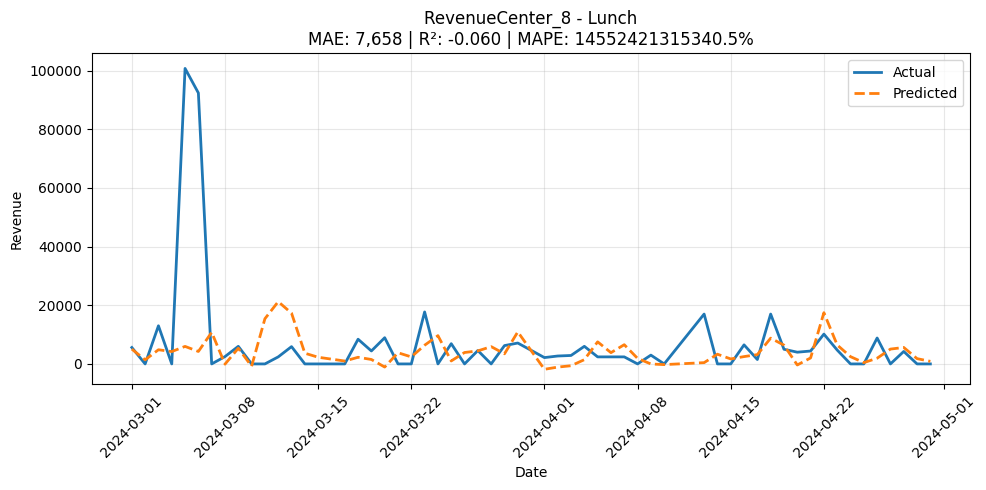

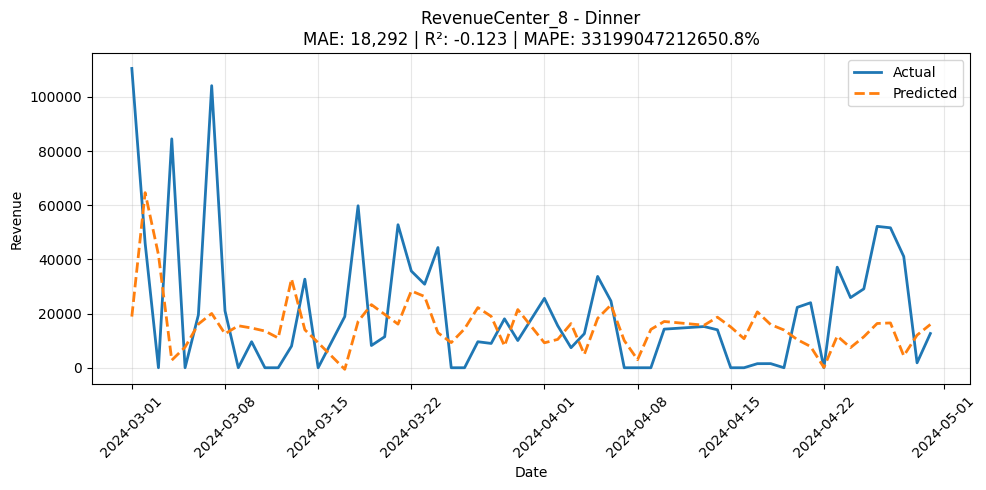

Saved plots & Excel → /content/RevenueCenter_8

Processing: RevenueCenter_1


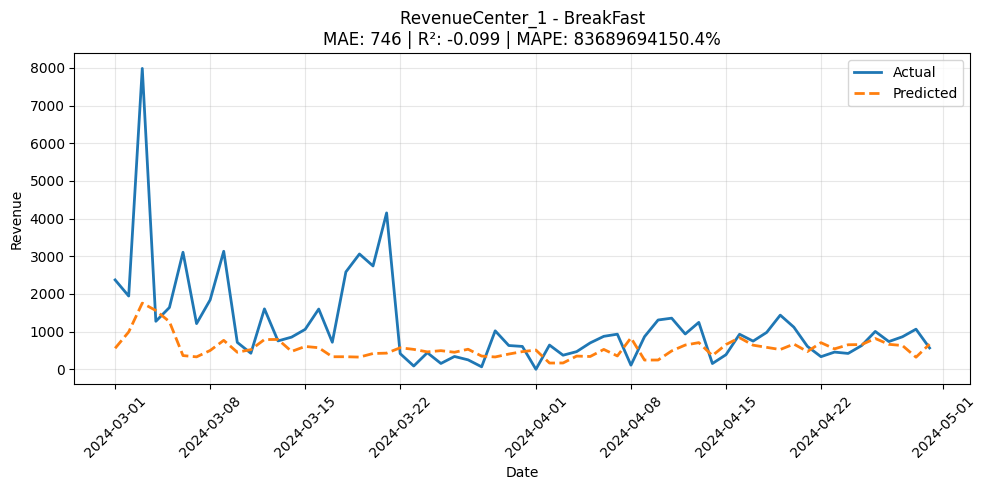

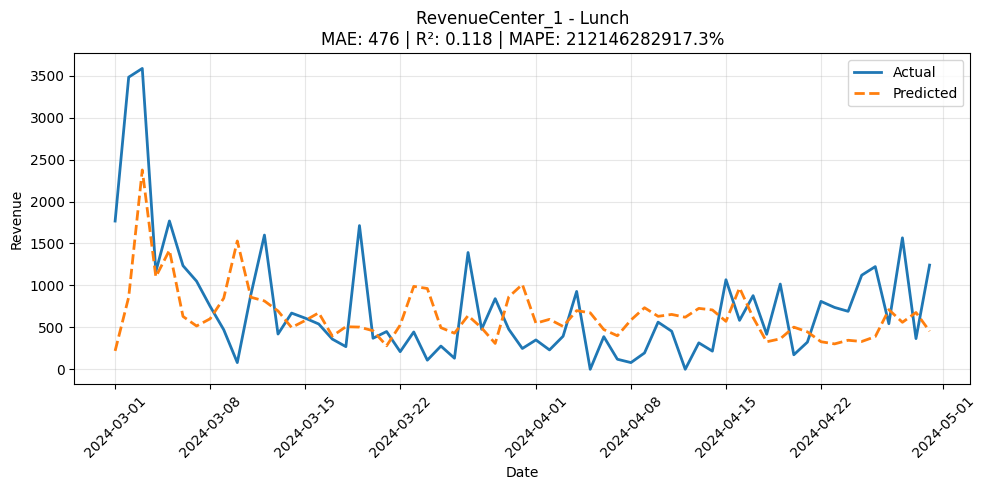

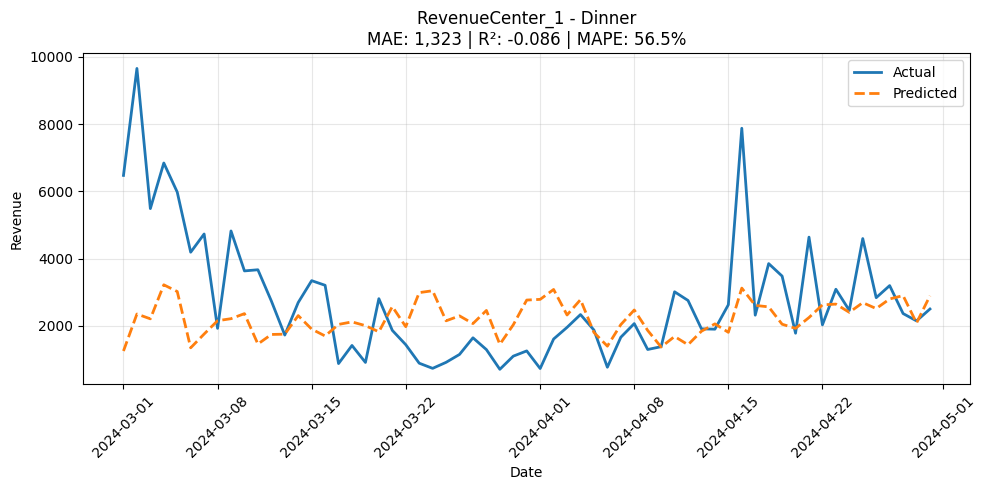

Saved plots & Excel → /content/RevenueCenter_1

Processing: RevenueCenter_6


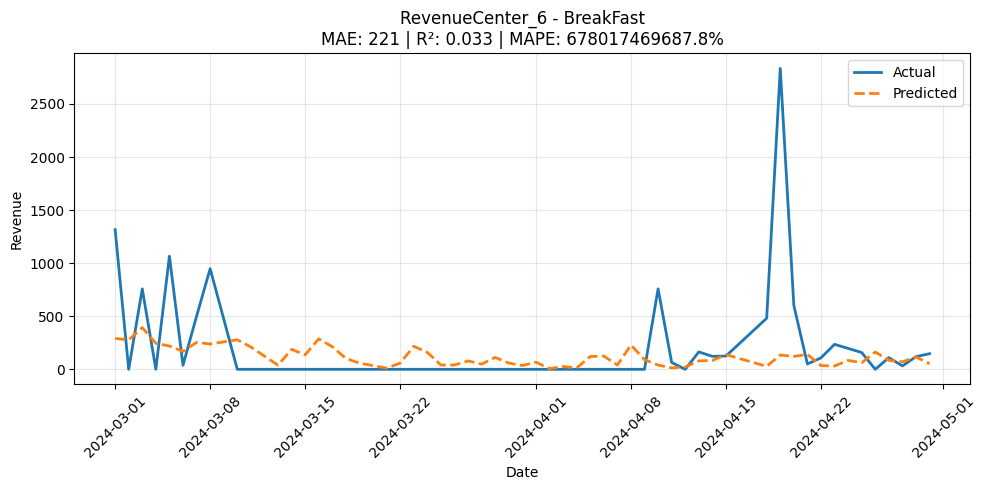

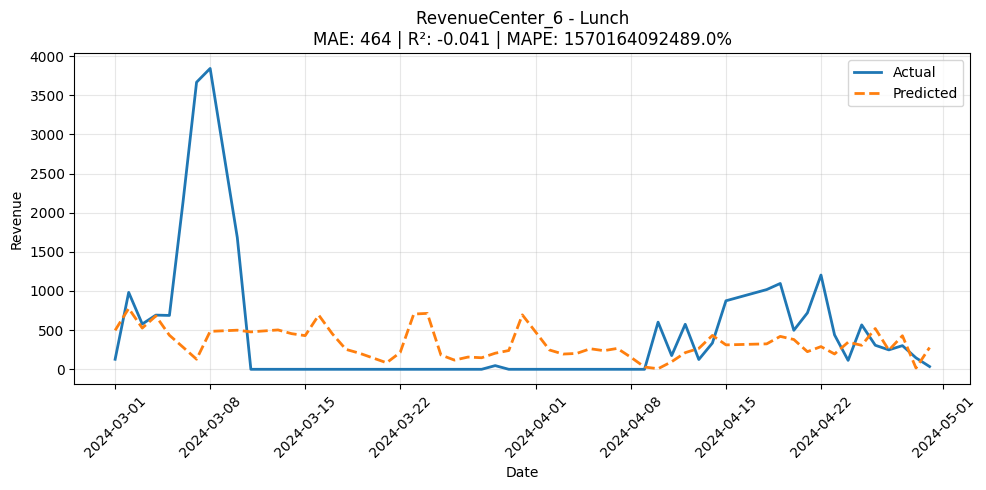

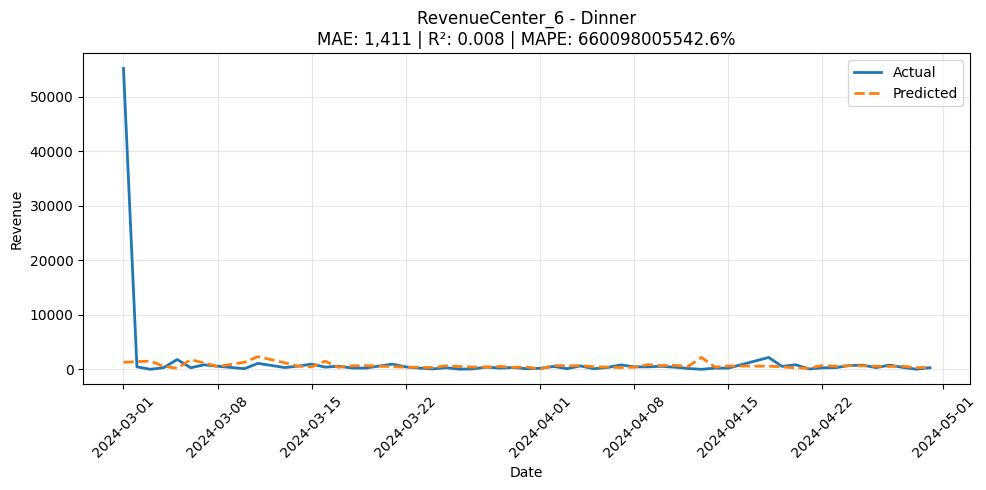

Saved plots & Excel → /content/RevenueCenter_6

Processing: RevenueCenter_9


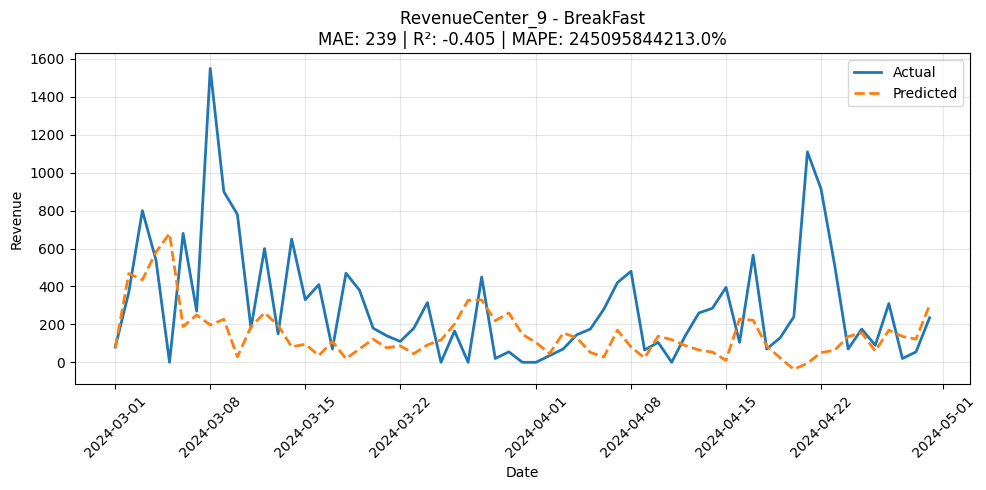

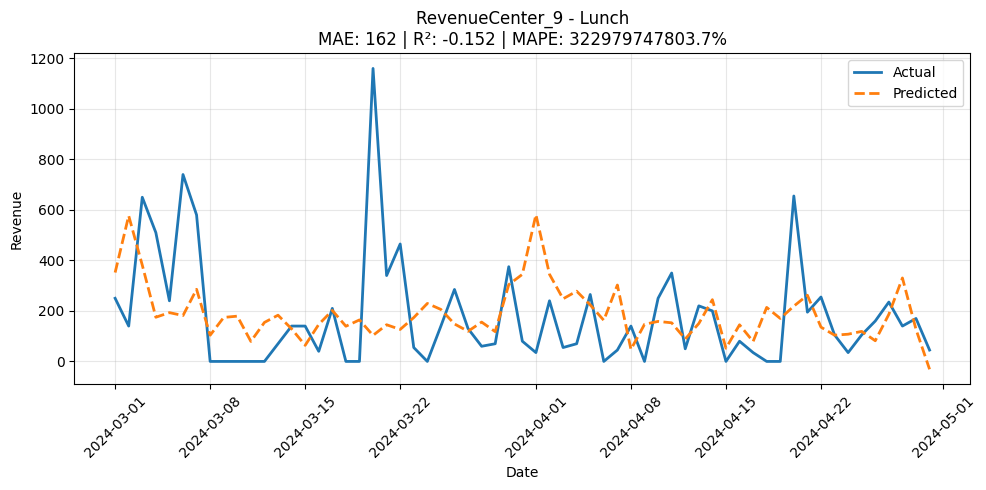

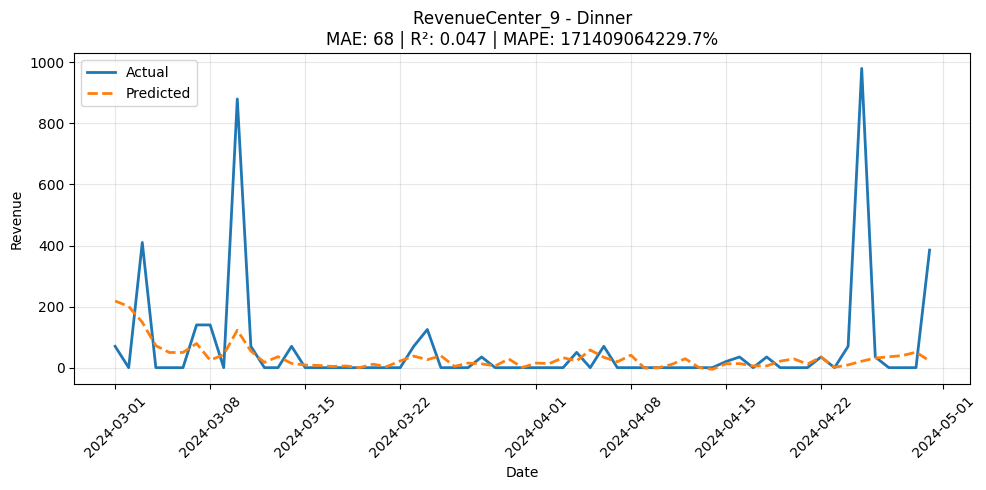

Saved plots & Excel → /content/RevenueCenter_9

Processing: RevenueCenter_2


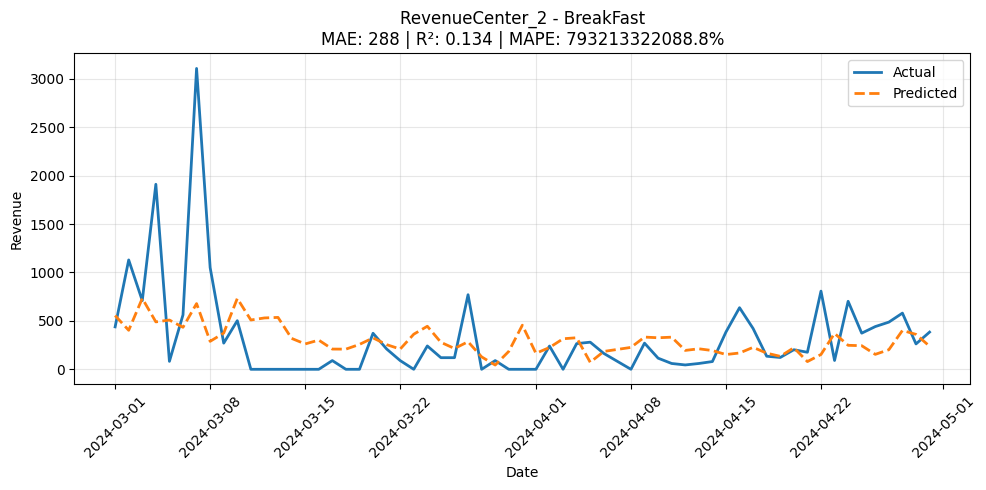

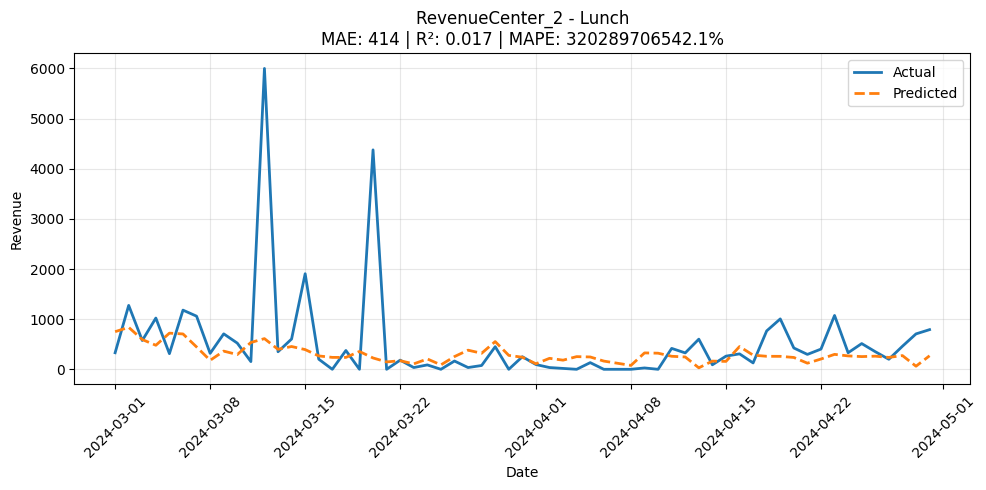

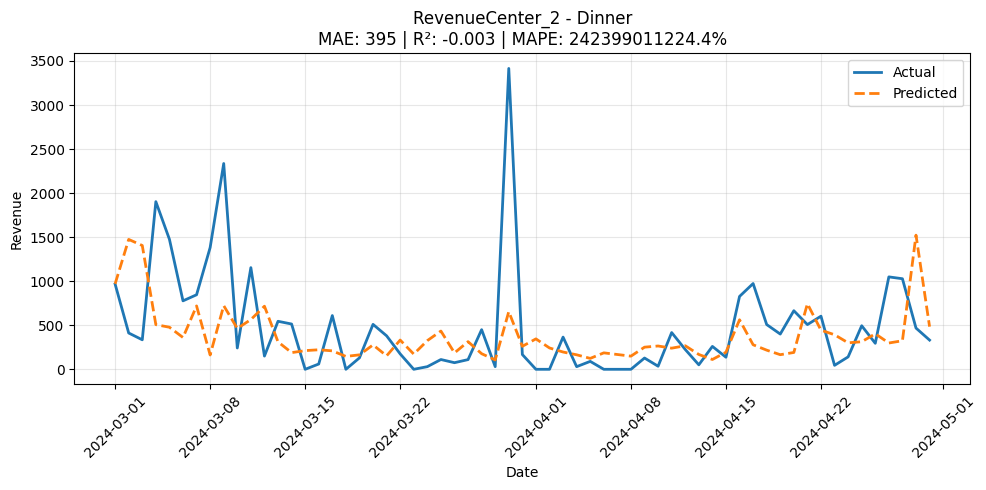

Saved plots & Excel → /content/RevenueCenter_2

Processing: RevenueCenter_3


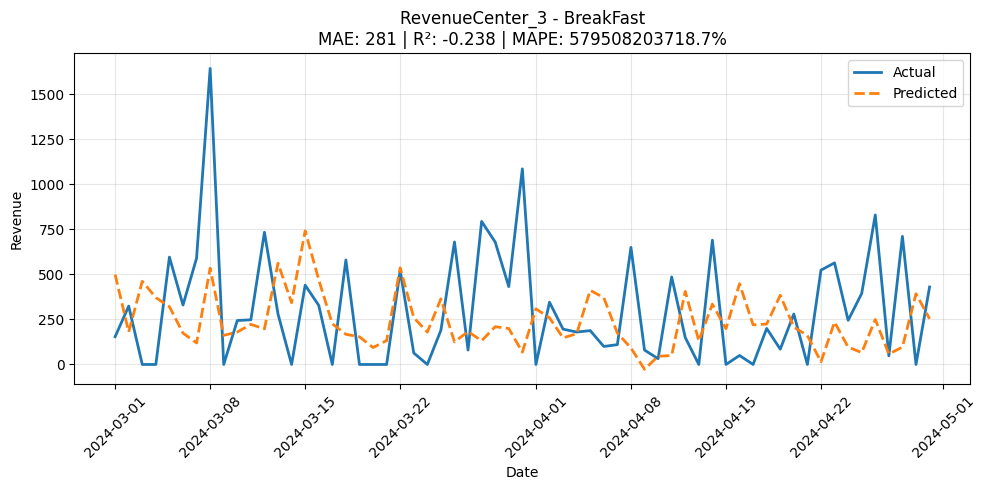

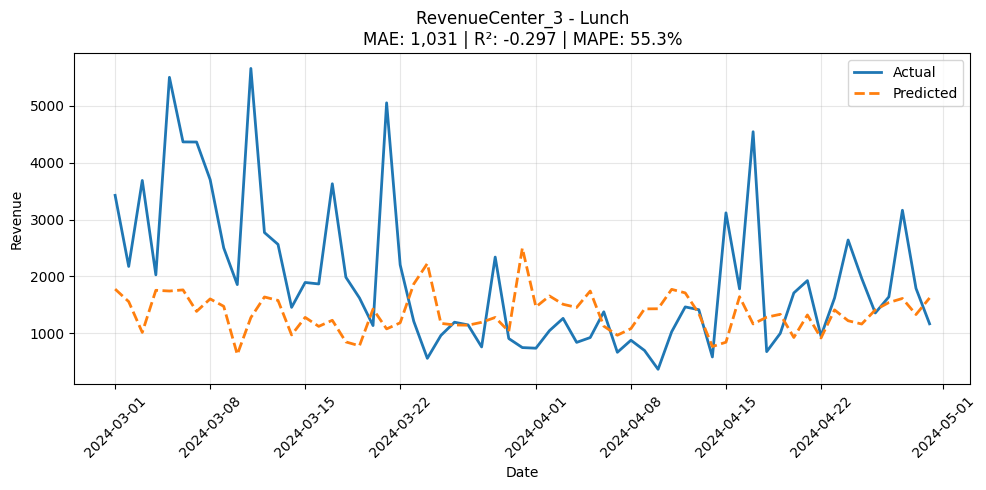

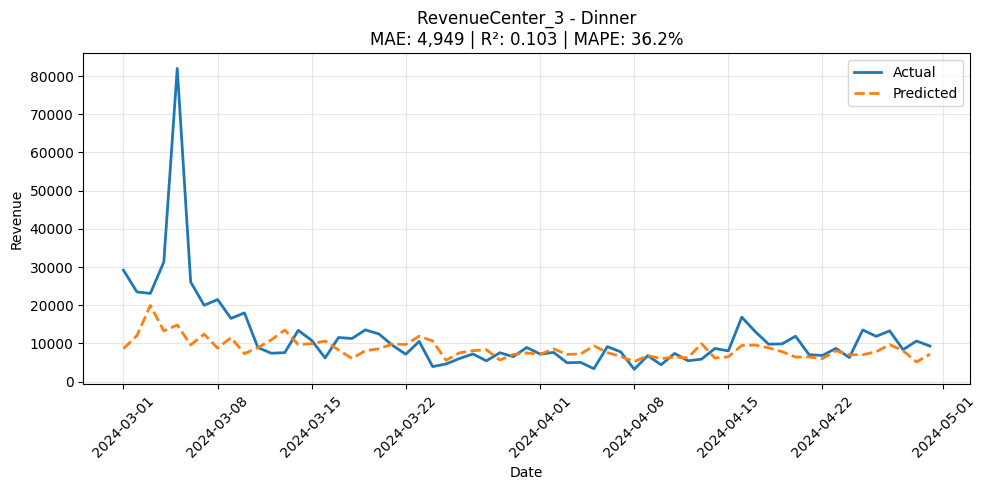

Saved plots & Excel → /content/RevenueCenter_3

Processing: RevenueCenter_4


CatBoostError: catboost/libs/metrics/metric.cpp:6935: All train targets are equal

In [5]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    # Create folder per Revenue Center
    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    # Load data
    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # Time-based features
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["day_of_month"] = df["Date"].dt.day

    features = [
        "average_temperature",
        "weather_code",
        "IsWeekend",
        "IsHoliday",
        "day_of_week",
        "month",
        "day_of_month"
    ]

    # Train-test split (last 2 months)
    split_date = df["Date"].max() - pd.DateOffset(months=2)
    split_index = df[df["Date"] > split_date].index[0]

    X_train = df.loc[:split_index-1, features]
    X_test  = df.loc[split_index:, features]

    test_dates = df.loc[split_index:, "Date"]

    meals = ["BreakFast", "Lunch", "Dinner"]
    error_list = []

    for meal in meals:

        y_train = df.loc[:split_index-1, meal]
        y_test  = df.loc[split_index:, meal]

        # CATBOOST MODEL

        model = CatBoostRegressor(
            iterations=1800,
            learning_rate=0.05,
            depth=6,
            l2_leaf_reg=3.0,
            loss_function="MAE",
            eval_metric="MAE",
            random_seed=42,
            verbose=False
        )

        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        mae_value  = mean_absolute_error(y_test, y_pred)
        r2_value   = r2_score(y_test, y_pred)
        mape_value = mape(y_test, y_pred)

        # Save metrics
        error_list.append({
            "Meal": meal,
            "MAE": mae_value,
            "R2": r2_value,
            "MAPE (%)": mape_value
        })

        # PLOT
        plt.figure(figsize=(10,5))
        plt.plot(test_dates, y_test, label="Actual", linewidth=2)
        plt.plot(test_dates, y_pred, "--", label="Predicted", linewidth=2)

        plt.title(
            f"{center_name} - {meal}\n"
            f"MAE: {mae_value:,.0f} | "
            f"R²: {r2_value:.3f} | "
            f"MAPE: {mape_value:.1f}%",
            fontsize=12
        )

        plt.xlabel("Date")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        plot_file = os.path.join(center_path, f"{meal}_catboost.png")
        plt.savefig(plot_file, dpi=300)
        plt.show()
        plt.close()

    """
    # SAVE EXCEL ERRORS

    error_df = pd.DataFrame(error_list)
    excel_path = os.path.join(center_path, f"{center_name}_errors_catboost.xlsx")
    error_df.to_excel(excel_path, index=False)
    """
    print(f"Saved plots & Excel → {center_path}")

print("\n ALL REVENUE CENTERS COMPLETED (CatBoost)")
